<a href="https://colab.research.google.com/github/LleilaA13/Thesis-MUL/blob/random-data-forgetting/notebooks/10_random_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##### This notebook uses the Lucent library, which is licensed under the Apache License, Version 2.0 (the "License");

In [ ]:
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
# https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

# Feature visualization: Pre vs. Post Machine Unlearning
This notebook demonstrates how machine unlearning affects the internal representations of neural networks by visualizing learned features before and after the unlearning process. We employ the **Lucent** library to generate feature visualizations and compare activation patterns across different layers of the network.

**Feature visualization:**
Generally speaking, neural networks are differentiable with respect to their inputs, meaning that certain inputs cause a certain behaviour.

Starting with random noise, we optimize an image to activate a particular neuron.



**How Lucent works:**
The core idea is to optimize the input image to the network such that a certain neuron or channel gets maximally excited.


**Random Forgetting with SalUn: Resnet-50 on Tiny ImageNet:**

We randomly select and forget **10% of the training data** and provide a comprehensive analysis of how unlearning affects different model components.


## Install, Import, Load model

In [1]:
!pip install --quiet git+https://github.com/greentfrapp/lucent.git

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 252.8/252.8 kB 21.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 49.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 86.3 MB/s eta 0:00:00


In [2]:
import torch
from torchvision import models
import matplotlib.pyplot as plt
import torchvision.transforms as T
from lucent.modelzoo.util import get_model_layers
from lucent.optvis import render, param, transform, objectives
import pandas as pd
import json

In [3]:
#fix seed for reproducibility
torch.manual_seed(0)

In [4]:

def load_resnet50(path):
  model = models.resnet50(num_classes=200)
  checkpoint = torch.load(path, map_location='cpu', weights_only=False)
  try:
      model.load_state_dict(checkpoint['state_dict'], strict=False)
  except:
      model.load_state_dict(checkpoint, strict=False)
  model.eval()
  return model

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
# Replace with the actual paths to your models
pretrained_model_path = '/content/drive/MyDrive/THESIS/resnet50_pretrained.pth'
unlearned_model_path = '/content/drive/MyDrive/THESIS/random-data-forgetting/good_results/random_forgetting_10percent_RL_tweak_conservative/RLcheckpoint.pth.tar'

# Load the pretrained and unlearned models
pretrained_model = load_resnet50(path=pretrained_model_path)
unlearned_model = load_resnet50(path=unlearned_model_path)

print("Pretrained model loaded successfully.")
print("Unlearned model loaded successfully.")

Pretrained model loaded successfully.
Unlearned model loaded successfully.


# Weight Analysis:

First of all, we need to show the most influenced weights, neurons, layers and channels.


After unlearning, we have made a script that runs an "influence" analysis to identify which network components were most affected by the unlearning process.

It does it by comparing the baseline model to the unlearned moded, by computing the difference between the weights of the two models at various levels:

    Layer level : measures the average changes per layers
    Channel level : measures changes per channel within layers.
    Weight level : measures changes for individual weigts.

Then it identifies and ranks the most influenced layers, channels, and weights, and finally in prepares a list of the most affected channels/layers for feature visualization


In [8]:
# paths to JSON files
summary_path = '/content/drive/MyDrive/THESIS/random-data-forgetting/multi_experiment_analysis/10percent/analysis_10percent.json'
targets_path = '/content/drive/MyDrive/THESIS/random-data-forgetting/multi_experiment_analysis/10percent/lucent_targets_10_percent.json'

# Load and Parse JSON Data
with open(summary_path, 'r') as f:
    influence_summary = json.load(f)

with open(targets_path, 'r') as f:
    lucent_targets = json.load(f)

print(" Data Loaded Successfully")
print(f"Model: {influence_summary['model_info']['architecture']}")
print(f"Total Parameters: {influence_summary['model_info']['total_parameters']:,}")
print(f"Loaded {len(lucent_targets)} visualization targets")

 Data Loaded Successfully
Model: ResNet50
Total Parameters: 23,917,832
Loaded 25 visualization targets


In [9]:
# Extract Key Findings from Summary
top_influences = influence_summary['top_influences']
statistics = influence_summary['statistics']

print(" Most Influenced Components:")
print(f"Layer: {top_influences['most_influenced_layer']} ({top_influences['max_layer_change']:.2f}%)")
print(f"Channel: {top_influences['most_influenced_channel']} ({top_influences['max_channel_change']:.2f}%)")
print(f"Weight: {top_influences['most_influenced_weight']} ({top_influences['max_weight_change']:.0f}%)")

print("\n📈 Analysis Statistics:")
print(f"Average layer change: {statistics['avg_layer_change']:.2f}%")
print(f"Average channel change: {statistics['avg_channel_change']:.2f}%")
print(f"Average weight change: {statistics['avg_weight_change']:.0f}%")


 Most Influenced Components:
Layer: conv1.weight (25.33%)
Channel: layer3.0.conv3.weight_ch902 (3978.55%)
Weight: layer3.5.conv2.weight_ch98_w644 (1406244%)

📈 Analysis Statistics:
Average layer change: 4.98%
Average channel change: 195.98%
Average weight change: 48407%


In [10]:
# Process Lucent Targets for Visualization
# Separate channels and layers
channels = [t for t in lucent_targets if t['type'] == 'channel']
layers = [t for t in lucent_targets if t['type'] == 'layer']

print(f"Found {len(channels)} channel targets and {len(layers)} layer targets")

channels_df = pd.DataFrame(channels)
layers_df = pd.DataFrame(layers)

# Display top 15 most influenced channels
print("\n Top 15 Most Influenced Channels:")
top_channels = channels_df.nlargest(15, 'influence_score')
for _, channel in top_channels.iterrows():
    print(f"  {channel['target']} - Score: {channel['influence_score']:.2f}")


Found 15 channel targets and 10 layer targets

 Top 15 Most Influenced Channels:
  layer3.0.conv3:902 - Score: 3978.55
  layer3.0.conv3:793 - Score: 1097.44
  conv1:23 - Score: 633.71
  layer3.5.conv2:98 - Score: 613.19
  layer3.1.conv2:123 - Score: 416.79
  layer3.4.conv2:200 - Score: 262.23
  layer3.0.conv3:651 - Score: 241.59
  layer4.0.conv2:390 - Score: 186.58
  conv1:35 - Score: 161.68
  layer3.0.conv2:175 - Score: 154.62
  layer3.0.conv3:20 - Score: 128.79
  layer2.0.conv2:34 - Score: 101.61
  layer3.0.conv2:230 - Score: 96.55
  layer4.1.conv2:23 - Score: 94.96
  layer3.0.conv2:56 - Score: 87.00


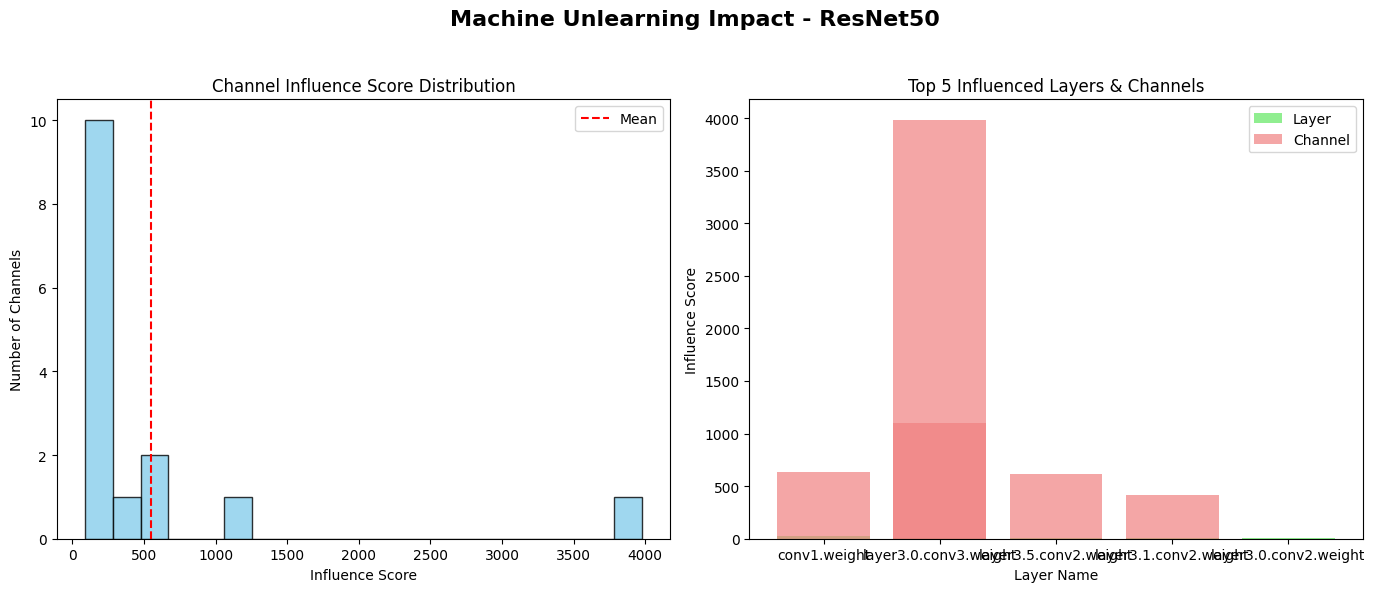

In [13]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Machine Unlearning Impact - ResNet50', fontsize=16, fontweight='bold')

# Plot 1: Channel influence score distribution
axes[0].hist(channels_df['influence_score'], bins=20, color='skyblue', edgecolor='black', alpha=0.8)
axes[0].set_title('Channel Influence Score Distribution')
axes[0].set_xlabel('Influence Score')
axes[0].set_ylabel('Number of Channels')
axes[0].axvline(channels_df['influence_score'].mean(), color='red', linestyle='--', label='Mean')
axes[0].legend()

# Plot 2a: Top 5 layer bar chart
axes[1].bar(layers_df.nlargest(5, 'influence_score')['layer_name'],
            layers_df.nlargest(5, 'influence_score')['influence_score'],
            color='lightgreen', label='Layer')
axes[1].set_title('Top 5 Influenced Layers')
axes[1].set_xlabel('Layer Name')
axes[1].set_ylabel('Influence Score')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend()

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


# Lucent feature visualization:
Now, we use the Lucent library to visualize these layers and channels most affected by the unlearning process.


**Objectives:**

What loss function do we want to minimize?

Or from another point of view, what part of the model do we want to understand?

We are trying to generate an image that causes a particular neuron or filter to activate strongly.



In [ ]:
#First, let's get the name of the model layers:
print(get_model_layers(pretrained_model))

['conv1', 'bn1', 'relu', 'maxpool', 'layer1', 'layer1_0', 'layer1_0_conv1', 'layer1_0_bn1', 'layer1_0_conv2', 'layer1_0_bn2', 'layer1_0_conv3', 'layer1_0_bn3', 'layer1_0_relu', 'layer1_0_downsample', 'layer1_0_downsample_0', 'layer1_0_downsample_1', 'layer1_1', 'layer1_1_conv1', 'layer1_1_bn1', 'layer1_1_conv2', 'layer1_1_bn2', 'layer1_1_conv3', 'layer1_1_bn3', 'layer1_1_relu', 'layer1_2', 'layer1_2_conv1', 'layer1_2_bn1', 'layer1_2_conv2', 'layer1_2_bn2', 'layer1_2_conv3', 'layer1_2_bn3', 'layer1_2_relu', 'layer2', 'layer2_0', 'layer2_0_conv1', 'layer2_0_bn1', 'layer2_0_conv2', 'layer2_0_bn2', 'layer2_0_conv3', 'layer2_0_bn3', 'layer2_0_relu', 'layer2_0_downsample', 'layer2_0_downsample_0', 'layer2_0_downsample_1', 'layer2_1', 'layer2_1_conv1', 'layer2_1_bn1', 'layer2_1_conv2', 'layer2_1_bn2', 'layer2_1_conv3', 'layer2_1_bn3', 'layer2_1_relu', 'layer2_2', 'layer2_2_conv1', 'layer2_2_bn1', 'layer2_2_conv2', 'layer2_2_bn2', 'layer2_2_conv3', 'layer2_2_bn3', 'layer2_2_relu', 'layer2_3', 

100%|██████████| 512/512 [04:02<00:00,  2.11it/s]



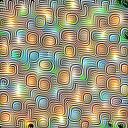

In [ ]:
# The default is optimizing for a channel/filter
#let's choose layer3.0.conv2:175 - Score: 154.62. In lucent it's "layer3_0_conv2"
obj = objectives.channel("layer3_0_conv2", 175)
_ = render.render_vis(pretrained_model, obj, show_inline=True)

100%|██████████| 512/512 [03:58<00:00,  2.15it/s]



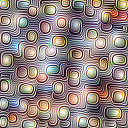

In [ ]:
#let's see the unlearned model:
obj = objectives.channel("layer3_0_conv2", 175)
_ = render.render_vis(unlearned_model, obj, show_inline=True)


100%|██████████| 512/512 [04:16<00:00,  1.99it/s]



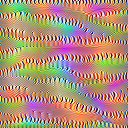

In [12]:
#Let's try now a layer that has been more influenced "layer3.0.conv3:793":
obj = objectives.channel("layer3_0_conv3", 793)
_ = render.render_vis(pretrained_model, obj, show_inline=True)


100%|██████████| 512/512 [04:18<00:00,  1.98it/s]



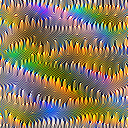

In [14]:
obj = objectives.channel("layer3_0_conv3", 793)
_ = render.render_vis(unlearned_model, obj, show_inline=True)